[Link](https://www.cis.upenn.edu/~aaroth/Papers/privacybook.pdf) to the book

**Theorem 3.20** (Advanced Composition). 
For all $ε, δ, δ′ ≥ 0$, the class of
$(ε, δ)$-differentially private mechanisms satisfies $(ε′, kδ + δ′)$-differential
privacy under k-fold adaptive composition for:
$$\epsilon\prime = \sqrt{2k \ln(1/\delta\prime)} ε + kε(e^{\epsilon} − 1)$$


Key Terms:

 - $ε$ : (Epsilon - Privacy Budget per Query)
        Measures the privacy loss of a single differentially private mechanism.
        Smaller ϵϵ means stronger privacy.
        Larger ϵϵ means weaker privacy (higher risk of leaking information).

 - $\delta$ : (Delta - Failure Probability per Query)
        Represents the probability that the privacy guarantee does not hold.
        If δ=0δ=0, the guarantee is strict (pure differential privacy).
        If δ>0δ>0, some probability of failure is allowed (approximate differential privacy).

 - $k$ : (Number of Queries / Compositions)
        The number of times we apply an (ϵ,δ)(ϵ,δ)-differentially private mechanism adaptively.

Advanced Composition Adjustments

Now, when we apply a mechanism $k$ times, the total privacy guarantee is updated as:

$\delta\prime$ : (Composed Epsilon - Total Privacy Loss after k Queries)
        Represents the new privacy loss after multiple queries.
        Computed as:
$$\epsilon\prime = \sqrt{2k \ln(1/\delta\prime)} ε + kε(e^{\epsilon} − 1)$$

$$ε + kε(e^{\epsilon} − 1)$$
Shows how privacy deteriorates over multiple queries.

$\delta\prime$(Additional Failure Probability for Composition)

We introduce an extra failure term δ′ to control privacy degradation.
The total failure probability becomes:
    
$$k\delta+\delta\prime$$
    
This ensures that the composition remains differentially private.

In [6]:
import numpy as np

def advanced_composition(epsilon, delta, k, delta_prime):

    sqrt_term = np.sqrt(2 * k * np.log(1 / delta_prime)) * epsilon
    linear_term = k * epsilon * (np.exp(epsilon) - 1)
    epsilon_total = sqrt_term + linear_term
    delta_total = k * delta + delta_prime
    
    return epsilon_total, delta_total

epsilon = 0.1
delta = 1e-5
k = 100
delta_prime = 1e-5

epsilon_total, delta_total = advanced_composition(epsilon, delta, k, delta_prime)
print(f"Total Epsilon: {epsilon_total}")
print(f"Total Delta: {delta_total}")

Total Epsilon: 5.850235092944558
Total Delta: 0.00101


Definition 3.1 $l1-sensitivity$. The L1-sensitivity of a function f :
$$N^{|X|} → R^{k} is: 
∆f = \max_{
x,y∈N^{|X|}
‖x−y‖_{1}=1}
‖f (x) − f (y)‖_{1}.$$

The l1 sensitivity of a function f captures the magnitude by which
a single individual’s data can change the function f in the worst case,
and therefore, intuitively, the uncertainty in the response that we must
introduce in order to hide the participation of a single individual.
Indeed, we will formalize this intuition: the sensitivity of a function
gives an upper bound on how much we must perturb its output to pre-
serve privacy. One noise distribution naturally lends itself to differential
privacy.


**NOTE**

$$
Δ_{1}(f)=\max_{D,D′}∥f(D)−f(D′)∥_{1}
$$

$∥⋅∥_{1}$ - is the L1 norm, which sums the absolute differences of the output values (for vector-valued functions, it’s the sum of absolute differences of each component).

1. $Sensitivity$ in DP refers to how much the result of a function or query can change when you make small changes to the input dataset (e.g., adding, removing, or modifying a single data point).

2. $L1-sensitivity$ specifically measures the maximum possible change in the absolute value of the output when you change just one data point in the input dataset. It focuses on the L1 norm, which calculates the total change in absolute terms.

In [37]:
def l1_sensitivity(D):

    num_attr = len(D[0])
    sensitivity = [0] * num_attr

    for i in range(len(D)):
        D_prime = D[:i] + D[i+1:] 
        for j in range(num_attr):
            orig_mean = np.mean([row[j] for row in D])
            neig_mean = np.mean([row[j] for row in D_prime])
            l1_sens = abs(orig_mean - neig_mean)
            sensitivity[j] = max(sensitivity[j], l1_sens)
    
    return sensitivity


def l1_sensitivity_v2(D_):
    sensitivities = np.zeros([len(D_), len(D_[0])])  
    
    for i in range(len(D_)):
        D_prime = D_[:i] + D_[i+1:]  
        for j in range(len(D_[0])):
            original_mean = np.mean([row[j] for row in D_])
            neighbor_mean = np.mean([row[j] for row in D_prime])
            sensitivity = abs(original_mean - neighbor_mean)
            sensitivities[i][j] = max(sensitivities[i][j], sensitivity) 
    return sensitivities




(59, 3)

$(\epsilon, 0)- \text{differential privacy}$ can be achieved by adding noise scaled
to $m/\epsilon$ to the true answer to each query.

ref: page 33

In [8]:
def laplace_noise_scale(D, epsilon):

    sensitivities = l1_sensitivity(D)
    scales = [m / epsilon for m in sensitivities]  
    return scales

# TEST: usecase-2.1

In [52]:
import csv
import numpy as np
import matplotlib.pyplot as plt

def parse_ctsv(filepath, delimiter):
    data = list()
    header = None
    with open(filepath, 'r') as f:
        reader = csv.reader(f, delimiter=delimiter)
        l = next(reader, None)
        for row in reader:
            data.append([float(x) for x in row])
    return data

D_file_path = "/staff/vincentajoubi/wp15-usecase-2.1_aux/usecase-2.1/input/deleteme.tsv" 
# deleteme.tsv refers only to the 3 columns of raw data
# namely (age, weight, height)
#D_prime_path = "/staff/vincentajoubi/wp15-usecase-2.1_aux/usecase-2.1/group-merged/group-merged.tsv"
D_ = parse_ctsv(D_file_path, "\t")
#D_P = parse_ctsv(D_prime_path, "\t")

D_prime = list()

sensitivities = np.zeros([len(D_), len(D_[0])])  
noise_list = np.zeros([len(D_), len(D_[0])])
noisy_D = np.zeros([len(D_), len(D_[0])])
epsilon = 0.5

for i in range(len(D_)):
    D_prime = D_[:i] + D_[i+1:]  
    for j in range(len(D_[0])):
        original_mean = np.mean([row[j] for row in D_])
        neighbor_mean = np.mean([row[j] for row in D_prime])
        sensitivity = abs(original_mean - neighbor_mean)
        sensitivities[i][j] = max(sensitivities[i][j], sensitivity) 
        noise = np.random.laplace(0, sensitivities[i][j] / epsilon)
        noise_list[i][j] = noise
        noisy_D[i][j] = D_[i][j] + noise


In [62]:
print(f"{'Noisy Dataset:':<48} {'Noise:':<38} {'Sensitivity:':<20}")
for a, b, c in zip(noisy_D, noise_list, sensitivities):
    print(f"{a}\t {b} \t{c}")

Noisy Dataset:                                   Noise:                                 Sensitivity:        
[ 19.06326297 154.94436951  48.72632965]	 [ 0.06326297 -0.05563049 -0.27367035] 	[0.01782583 0.2270602  0.1862069 ]
[ 18.94036681 168.97119412  46.96804615]	 [-0.05963319 -0.02880588  0.96804615] 	[0.01782583 0.01431911 0.23793103]
[ 20.00037839 157.01308093  47.16648928]	 [0.00037839 0.01308093 0.16648928] 	[0.00058445 0.19257744 0.22068966]
[ 18.99509018 171.06015629  67.33570424]	 [-0.00490982  0.06015629 -0.66429576] 	[0.01782583 0.04880187 0.14137931]
[ 21.00471888 165.9141233   55.81317821]	 [ 0.00471888 -0.0858767  -0.18682179] 	[0.01665693 0.03740503 0.06551724]
[ 19.99955564 166.931645    49.11850308]	 [-4.44359176e-04 -6.83550043e-02 -5.81496920e-01] 	[0.00058445 0.02016365 0.17413793]
[ 18.9831194  175.75246222  71.55914389]	 [-0.0168806   0.75246222 -0.44085611] 	[0.01782583 0.11776739 0.21034483]
[ 20.88766693 165.08176051  54.19029342]	 [-0.11233307  0.08176051  0.

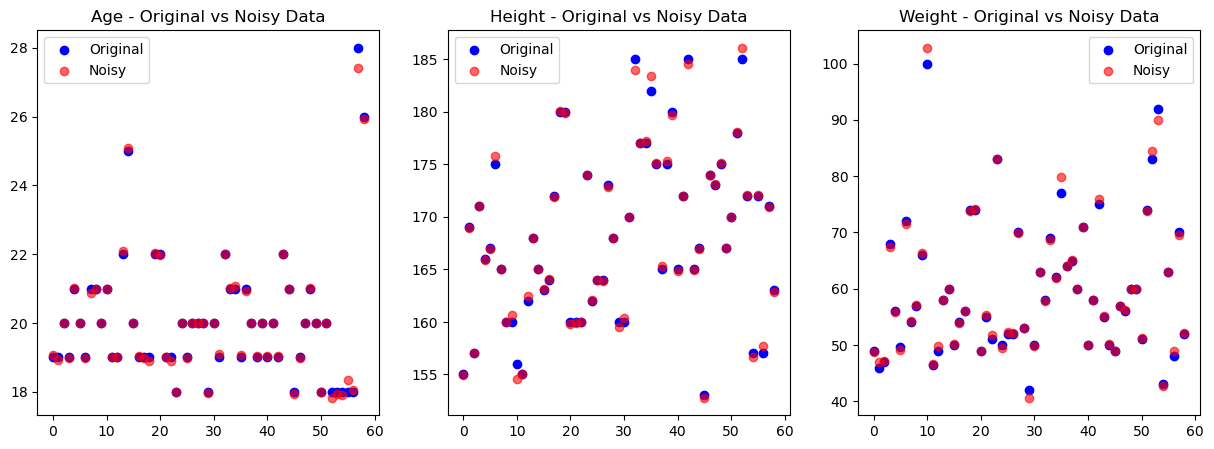

In [61]:
D = np.array(D_)
noisy_D = np.array(noisy_D)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
attributes = ["Age", "Height", "Weight"]
for i in range(3):
    axs[i].scatter(range(len(np.array(D_)[:, i])), np.array(D_)[:, i], label="Original", color="blue")
    axs[i].scatter(range(len(noisy_D[:, i])), noisy_D[:, i], label="Noisy", color="red", alpha=0.6)
    axs[i].set_title(f"{attributes[i]} - Original vs Noisy Data")
    axs[i].legend()

plt.show()

